In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_util = pd.read_csv("../data/processed/utilization_clean.csv")
df_growth = pd.read_csv("../data/processed/growth_clean.csv")

df_util["Record_Date"] = pd.to_datetime(df_util["Record_Date"])

print("Utilization loaded:", df_util.shape)
print("Growth loaded:", df_growth.shape)

Utilization loaded: (1530, 8)
Growth loaded: (35, 3)


In [3]:
avg_util = df_util.groupby("Device_Type")[["Bandwidth_Utilization_Pct", 
                                            "CPU_Utilization_Pct", 
                                            "Memory_Utilization_Pct", 
                                            "Port_Utilization_Pct"]].mean().round(2)
print(avg_util)

              Bandwidth_Utilization_Pct  CPU_Utilization_Pct  \
Device_Type                                                    
Access Point                      42.83                30.16   
Firewall                          69.07                51.89   
Router                            61.86                42.11   
Server                            24.77                62.32   
Switch                            51.58                29.97   

              Memory_Utilization_Pct  Port_Utilization_Pct  
Device_Type                                                 
Access Point                   37.07                 59.40  
Firewall                       60.01                 49.51  
Router                         54.26                 50.60  
Server                         71.96                 34.93  
Switch                         43.16                 70.26  


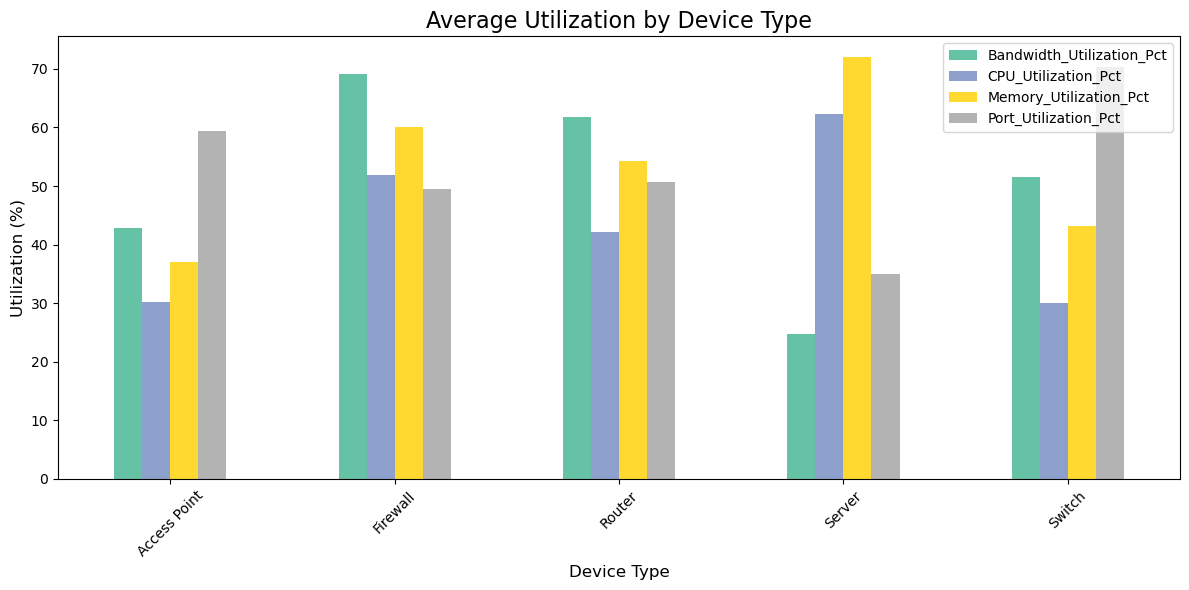

In [5]:
avg_util.plot(kind="bar", figsize=(12, 6), colormap="Set2")
plt.title("Average Utilization by Device Type", fontsize=16)
plt.xlabel("Device Type", fontsize=12)
plt.ylabel("Utilization (%)", fontsize=12)
plt.xticks(rotation=45)
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("../data/processed/avg_utilization_by_type.png")
plt.show()

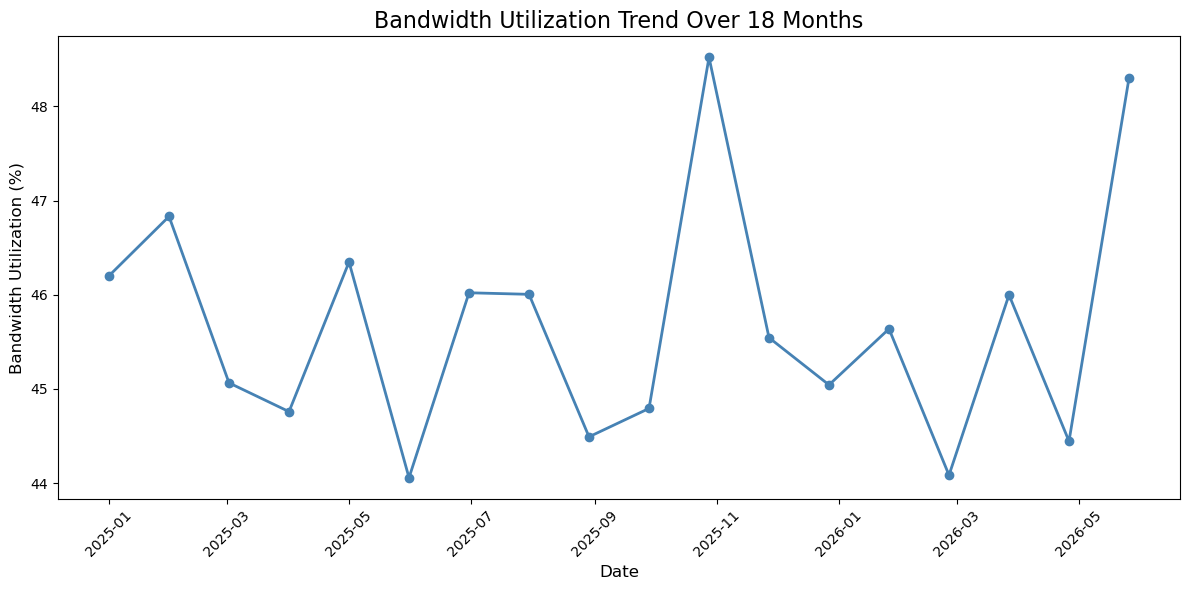

In [7]:
bandwidth_trend = df_util.groupby("Record_Date")["Bandwidth_Utilization_Pct"].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(bandwidth_trend["Record_Date"], bandwidth_trend["Bandwidth_Utilization_Pct"], 
         marker="o", color="steelblue", linewidth=2)
plt.title("Bandwidth Utilization Trend Over 18 Months", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Bandwidth Utilization (%)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../data/processed/bandwidth_trend.png")
plt.show()

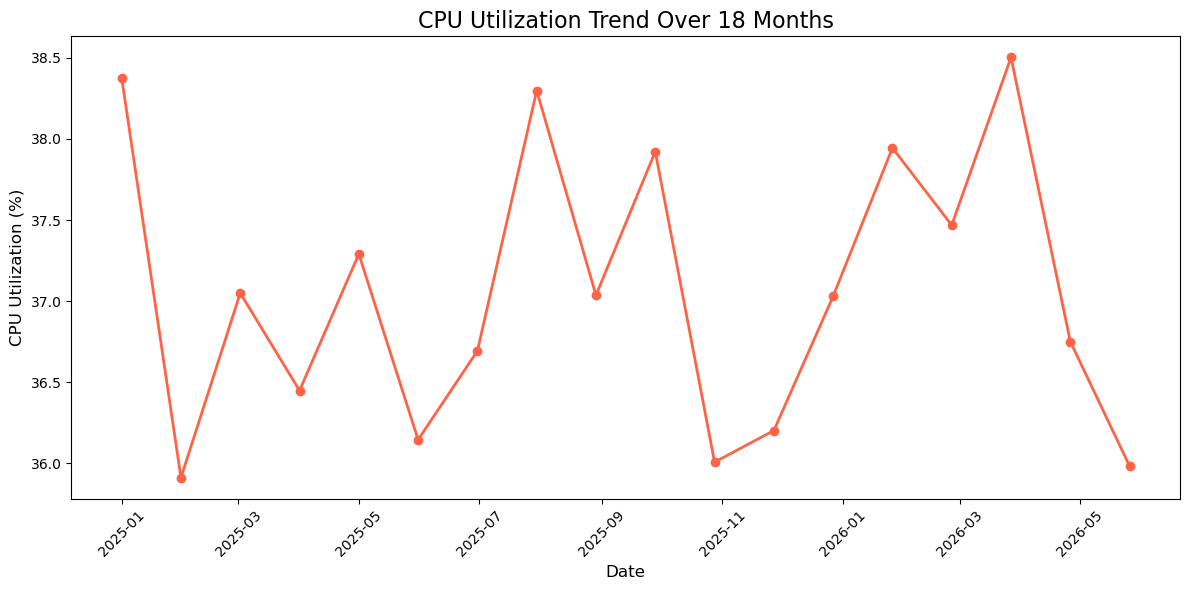

In [9]:
cpu_trend = df_util.groupby("Record_Date")["CPU_Utilization_Pct"].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(cpu_trend["Record_Date"], cpu_trend["CPU_Utilization_Pct"], 
         marker="o", color="tomato", linewidth=2)
plt.title("CPU Utilization Trend Over 18 Months", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("CPU Utilization (%)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../data/processed/cpu_trend.png")
plt.show()

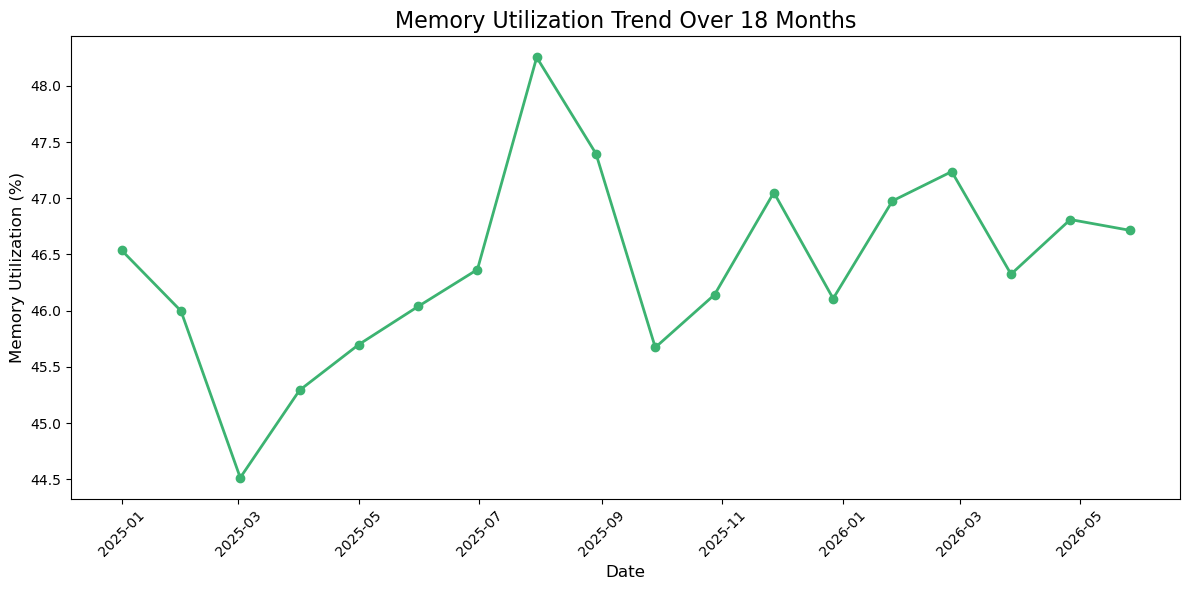

In [11]:
memory_trend = df_util.groupby("Record_Date")["Memory_Utilization_Pct"].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(memory_trend["Record_Date"], memory_trend["Memory_Utilization_Pct"], 
         marker="o", color="mediumseagreen", linewidth=2)
plt.title("Memory Utilization Trend Over 18 Months", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Memory Utilization (%)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../data/processed/memory_trend.png")
plt.show()

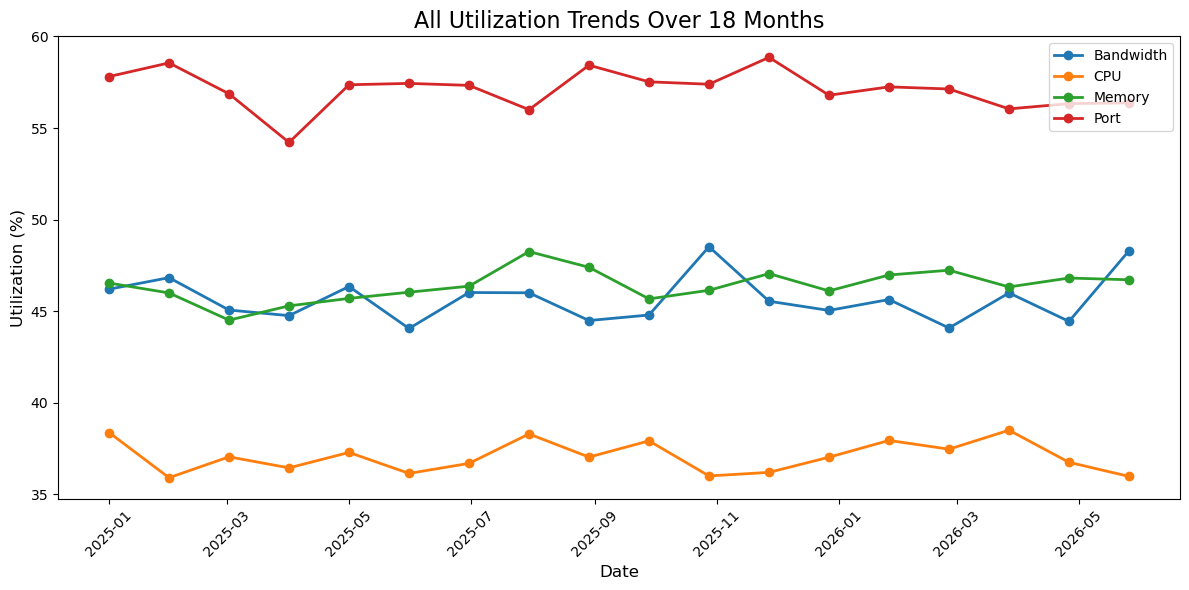

In [13]:
all_trends = df_util.groupby("Record_Date")[["Bandwidth_Utilization_Pct",
                                              "CPU_Utilization_Pct",
                                              "Memory_Utilization_Pct",
                                              "Port_Utilization_Pct"]].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(all_trends["Record_Date"], all_trends["Bandwidth_Utilization_Pct"], marker="o", label="Bandwidth", linewidth=2)
plt.plot(all_trends["Record_Date"], all_trends["CPU_Utilization_Pct"], marker="o", label="CPU", linewidth=2)
plt.plot(all_trends["Record_Date"], all_trends["Memory_Utilization_Pct"], marker="o", label="Memory", linewidth=2)
plt.plot(all_trends["Record_Date"], all_trends["Port_Utilization_Pct"], marker="o", label="Port", linewidth=2)
plt.title("All Utilization Trends Over 18 Months", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Utilization (%)", fontsize=12)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../data/processed/all_trends.png")
plt.show()

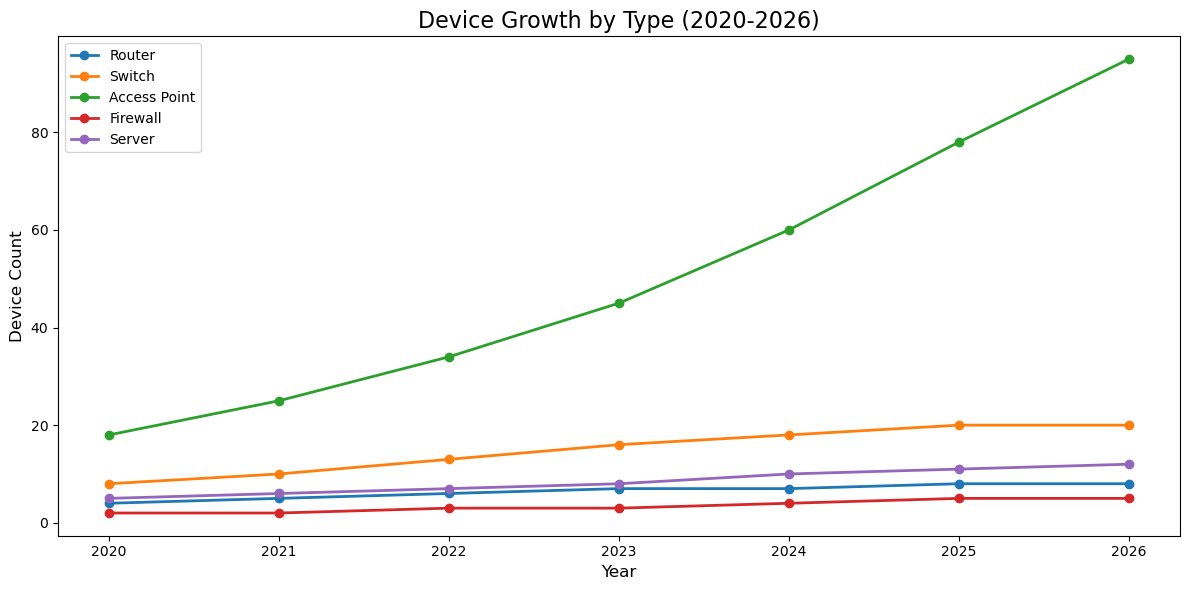

In [15]:
plt.figure(figsize=(12, 6))
for device_type in df_growth["Device_Type"].unique():
    data = df_growth[df_growth["Device_Type"] == device_type]
    plt.plot(data["Year"], data["Device_Count"], marker="o", label=device_type, linewidth=2)

plt.title("Device Growth by Type (2020-2026)", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Device Count", fontsize=12)
plt.legend()
plt.xticks(df_growth["Year"].unique())
plt.tight_layout()
plt.savefig("../data/processed/device_growth_trend.png")
plt.show()

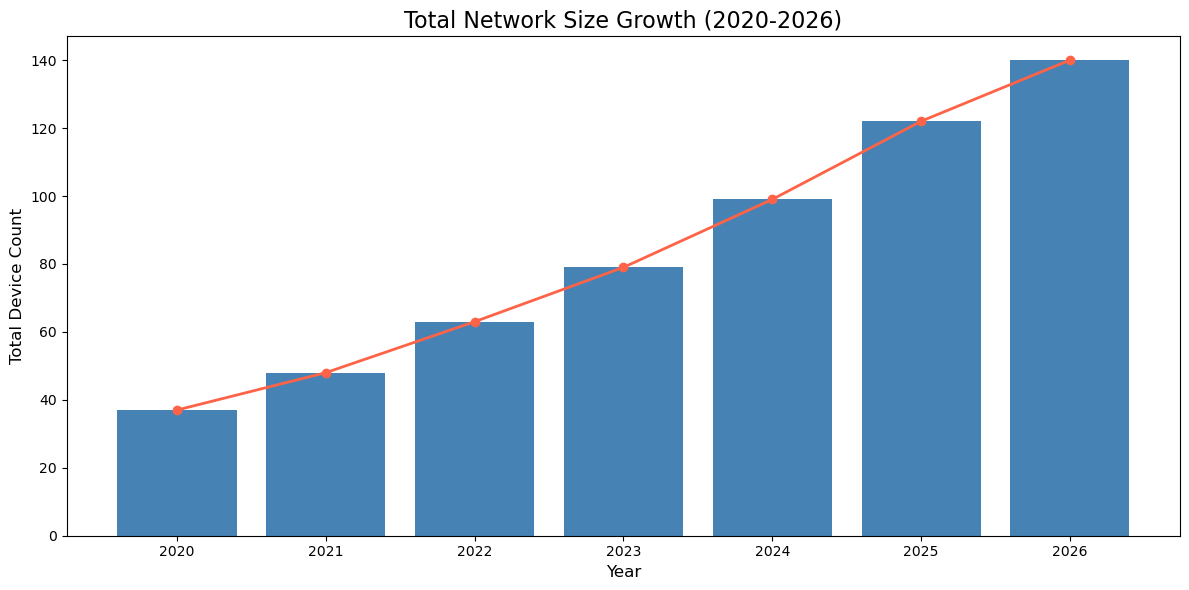

In [17]:
total_growth = df_growth.groupby("Year")["Device_Count"].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.bar(total_growth["Year"], total_growth["Device_Count"], color="steelblue")
plt.plot(total_growth["Year"], total_growth["Device_Count"], marker="o", color="tomato", linewidth=2)
plt.title("Total Network Size Growth (2020-2026)", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Device Count", fontsize=12)
plt.xticks(total_growth["Year"])
plt.tight_layout()
plt.savefig("../data/processed/total_growth_trend.png")
plt.show()

In [19]:
growth_summary = []

for device_type in df_growth["Device_Type"].unique():
    data = df_growth[df_growth["Device_Type"] == device_type].sort_values("Year")
    start_count = data["Device_Count"].iloc[0]
    end_count = data["Device_Count"].iloc[-1]
    growth_rate = round(((end_count - start_count) / start_count) * 100, 2)
    growth_summary.append({
        "Device_Type": device_type,
        "Count_2020": start_count,
        "Count_2026": end_count,
        "Growth_Rate_Pct": growth_rate
    })

df_growth_summary = pd.DataFrame(growth_summary).sort_values("Growth_Rate_Pct", ascending=False)
print(df_growth_summary)

    Device_Type  Count_2020  Count_2026  Growth_Rate_Pct
2  Access Point          18          95           427.78
1        Switch           8          20           150.00
3      Firewall           2           5           150.00
4        Server           5          12           140.00
0        Router           4           8           100.00


In [21]:
print("=" * 50)
print("         TREND ANALYSIS SUMMARY")
print("=" * 50)
print(f"Analysis Period:        2020 - 2026")
print(f"Utilization Period:     Jan 2025 - Jun 2026")
print(f"\nAverage Utilization Across All Devices:")
print(f"  Bandwidth:  {df_util['Bandwidth_Utilization_Pct'].mean().round(2)}%")
print(f"  CPU:        {df_util['CPU_Utilization_Pct'].mean().round(2)}%")
print(f"  Memory:     {df_util['Memory_Utilization_Pct'].mean().round(2)}%")
print(f"  Port:       {df_util['Port_Utilization_Pct'].mean().round(2)}%")
print(f"\nFastest Growing Device Type:")
fastest = df_growth_summary.iloc[0]
print(f"  {fastest['Device_Type']} — {fastest['Growth_Rate_Pct']}% growth since 2020")
print("=" * 50)

         TREND ANALYSIS SUMMARY
Analysis Period:        2020 - 2026
Utilization Period:     Jan 2025 - Jun 2026

Average Utilization Across All Devices:
  Bandwidth:  45.67%
  CPU:        37.06%
  Memory:     46.4%
  Port:       57.09%

Fastest Growing Device Type:
  Access Point — 427.78% growth since 2020
